# Лабораторная работа: Линейные модели, SVM и деревья решений

## Цель лабораторной работы
Изучение линейных моделей, SVM и деревьев решений.

## Описание задания

В рамках данной лабораторной работы необходимо выполнить следующие шаги:

1. **Выбор набора данных (датасета)**: Выбрать датасет для решения задачи классификации.
2. **Предварительная обработка данных**: В случае необходимости провести удаление или заполнение пропусков и кодирование категориальных признаков.
3. **Разделение выборки**: С использованием метода `train_test_split` разделить выборку на обучающую и тестовую.
4. **Обучение моделей**: Обучить следующие модели:
    * Логистическая регрессия (как линейная модель для классификации).
    * Метод опорных векторов (SVM).
    * Дерево решений.
5. **Оценка качества моделей**: Оценить качество моделей с помощью двух подходящих для задачи метрик. Сравнить качество полученных моделей.
6. **Анализ дерева решений**: Построить график, показывающий важность признаков в дереве решений. Визуализировать дерево решений или вывести правила дерева решений в текстовом виде.

Выполним импорт необходимых библиотек

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

Загрузка и первичный анализ

In [46]:
df = sns.load_dataset('titanic')
print('Первые пять строк')
print(df.head())
print(f"\nТипы данных и пропуски:")
print(df.info())

print(f"\nСтатистика числовых признаков:")
print(df.describe())

print("Распределение целевой переменной (выжил/не выжил):")
print(df['survived'].value_counts())

Первые пять строк
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Типы данных и пропуски:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       ----------

Проверим на наличие пропусков

In [47]:
df_processed = df.copy()

print("Исходное количество пропусков:")
print(df_processed.isnull().sum())

# Удаляем: 'alive' (дублирует survived), 'deck' (много пропусков), 
# 'class' (дублирует pclass), 'who' (дублирует sex и age), 
# 'adult_male' (дублирует sex и age), 'embark_town' (дублирует embarked)
columns_to_drop = ['alive', 'deck', 'class', 'who', 'adult_male', 'embark_town']
df_processed = df_processed.drop(columns=columns_to_drop)

print("Признаки после удаления дублирующих колонок:")
print(df_processed.columns.tolist())


Исходное количество пропусков:
survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64
Признаки после удаления дублирующих колонок:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'alone']


Заполняем пропуска. Age заполним медианой, а embarked - модой.

In [48]:
age_medians = df_processed.groupby(['sex', 'pclass'])['age'].median()
for (sex, pclass), median_age in age_medians.items():
    mask = (df_processed['sex'] == sex) & (df_processed['pclass'] == pclass) & (df_processed['age'].isnull())
    df_processed.loc[mask, 'age'] = median_age

embarked_mode = df_processed['embarked'].mode()[0]
df_processed['embarked'] = df_processed['embarked'].fillna(embarked_mode)
print(f"Пропуски после заполнения возраста: {df_processed['age'].isnull().sum()}")
print(f"Пропуски после заполнения порта посадки: {df_processed['embarked'].isnull().sum()}")

Пропуски после заполнения возраста: 0
Пропуски после заполнения порта посадки: 0


Далее кодируем категориальные признаки

In [49]:
# LabelEncoder для sex (male/female)
le_sex = LabelEncoder()
df_processed['sex_encoded'] = le_sex.fit_transform(df_processed['sex'])

# One-hot кодирование для embarked
embarked_dummies = pd.get_dummies(df_processed['embarked'], prefix='embarked', drop_first=True)
df_processed = pd.concat([df_processed, embarked_dummies], axis=1)

# Кодирование alone (True/False -> 1/0)
df_processed['alone_encoded'] = df_processed['alone'].astype(int)

# Удаляем исходные текстовые колонки, которые больше не нужны
df_processed = df_processed.drop(columns=['sex', 'embarked', 'alone'])

print("Признаки после кодирования:")
print(df_processed.columns.tolist())
print(df_processed.head())

Признаки после кодирования:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'sex_encoded', 'embarked_Q', 'embarked_S', 'alone_encoded']
   survived  pclass   age  sibsp  parch     fare  sex_encoded  embarked_Q  \
0         0       3  22.0      1      0   7.2500            1       False   
1         1       1  38.0      1      0  71.2833            0       False   
2         1       3  26.0      0      0   7.9250            0       False   
3         1       1  35.0      1      0  53.1000            0       False   
4         0       3  35.0      0      0   8.0500            1       False   

   embarked_S  alone_encoded  
0        True              0  
1       False              0  
2        True              1  
3        True              0  
4        True              1  


Выбираем признаки для модели

In [50]:
feature_columns = ['pclass', 'age', 'sibsp', 'parch', 'fare', 
                   'sex_encoded', 'alone_encoded', 'embarked_Q', 'embarked_S']

X = df_processed[feature_columns]
y = df_processed['survived']

print("Признаки для модели (X):")
print(X.head())
print(f"\nРазмерность X: {X.shape}")
print(f"Размерность y: {y.shape}")

Признаки для модели (X):
   pclass   age  sibsp  parch     fare  sex_encoded  alone_encoded  \
0       3  22.0      1      0   7.2500            1              0   
1       1  38.0      1      0  71.2833            0              0   
2       3  26.0      0      0   7.9250            0              1   
3       1  35.0      1      0  53.1000            0              0   
4       3  35.0      0      0   8.0500            1              1   

   embarked_Q  embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  

Размерность X: (891, 9)
Размерность y: (891,)


Масштабируем признаки

In [51]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=feature_columns)

print("Статистика признаков после масштабирования:")
print(X_scaled_df.describe())

Статистика признаков после масштабирования:
             pclass           age         sibsp         parch          fare  \
count  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02  8.910000e+02   
mean  -8.772133e-17  2.153160e-16  4.386066e-17  5.382900e-17  3.987333e-18   
std    1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00  1.000562e+00   
min   -1.566107e+00 -2.157819e+00 -4.745452e-01 -4.736736e-01 -6.484217e-01   
25%   -3.693648e-01 -5.724938e-01 -4.745452e-01 -4.736736e-01 -4.891482e-01   
50%    8.273772e-01 -2.340704e-01 -4.745452e-01 -4.736736e-01 -3.573909e-01   
75%    8.273772e-01  5.179814e-01  4.327934e-01 -4.736736e-01 -2.424635e-02   
max    8.273772e-01  3.827009e+00  6.784163e+00  6.974147e+00  9.667167e+00   

        sex_encoded  alone_encoded  embarked_Q    embarked_S  
count  8.910000e+02   8.910000e+02  891.000000  8.910000e+02  
mean  -1.156327e-16  -6.379733e-17    0.000000 -8.373399e-17  
std    1.000562e+00   1.000562e+00    1.000562  1.00056

Разделим данные на обучающую (80%) и тестовую (20%) выборки с сохранением пропорций классов.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки X_train: {X_train.shape}")
print(f"Размер тестовой выборки X_test: {X_test.shape}")
print(f"Размер обучающей выборки y_train: {y_train.shape}")
print(f"Размер тестовой выборки y_test: {y_test.shape}")

print("\nРаспределение классов в обучающей выборке:")
print(y_train.value_counts(normalize=True))
print("\nРаспределение классов в тестовой выборке:")
print(y_test.value_counts(normalize=True))

Размер обучающей выборки X_train: (712, 9)
Размер тестовой выборки X_test: (179, 9)
Размер обучающей выборки y_train: (712,)
Размер тестовой выборки y_test: (179,)

Распределение классов в обучающей выборке:
survived
0    0.616573
1    0.383427
Name: proportion, dtype: float64

Распределение классов в тестовой выборке:
survived
0    0.614525
1    0.385475
Name: proportion, dtype: float64


Оценка качества Логистической регрессии:
Accuracy: 0.8045

Classification Report:
               precision    recall  f1-score   support

    Не выжил       0.82      0.88      0.85       110
       Выжил       0.78      0.68      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



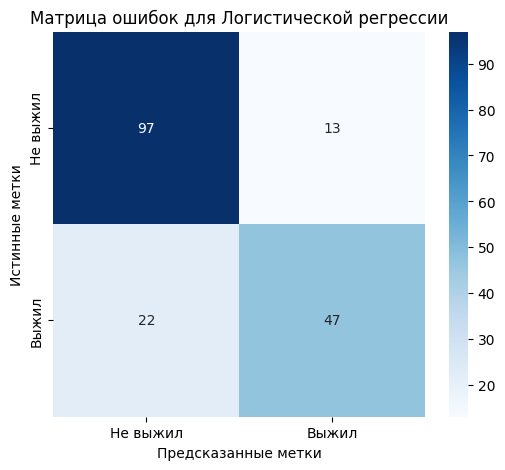


Оценка качества SVM:
Accuracy: 0.8045

Classification Report:
               precision    recall  f1-score   support

    Не выжил       0.80      0.91      0.85       110
       Выжил       0.81      0.64      0.72        69

    accuracy                           0.80       179
   macro avg       0.81      0.77      0.78       179
weighted avg       0.81      0.80      0.80       179



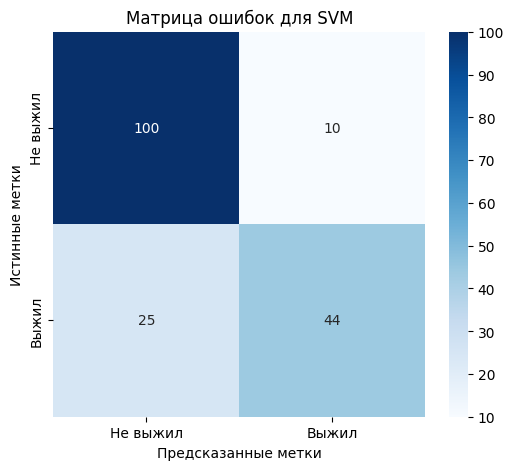


Оценка качества Дерева решений:
Accuracy: 0.8045

Classification Report:
               precision    recall  f1-score   support

    Не выжил       0.82      0.87      0.85       110
       Выжил       0.77      0.70      0.73        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



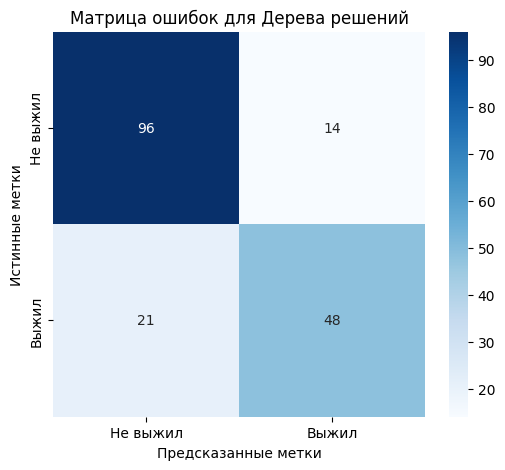

In [53]:
# --- Логистическая регрессия ---
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

# --- SVM ---
svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

# --- Дерево решений ---
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

# --- Оценка качества Логистической регрессии ---
print("Оценка качества Логистической регрессии:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, target_names=['Не выжил', 'Выжил']))

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'])
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок для Логистической регрессии')
plt.show()

# --- Оценка качества SVM ---
print("\nОценка качества SVM:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_svm, target_names=['Не выжил', 'Выжил']))

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'])
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок для SVM')
plt.show()

# --- Оценка качества Дерева решений ---
print("\nОценка качества Дерева решений:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt, target_names=['Не выжил', 'Выжил']))

cm_dt = confusion_matrix(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", xticklabels=['Не выжил', 'Выжил'], yticklabels=['Не выжил', 'Выжил'])
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок для Дерева решений')
plt.show()

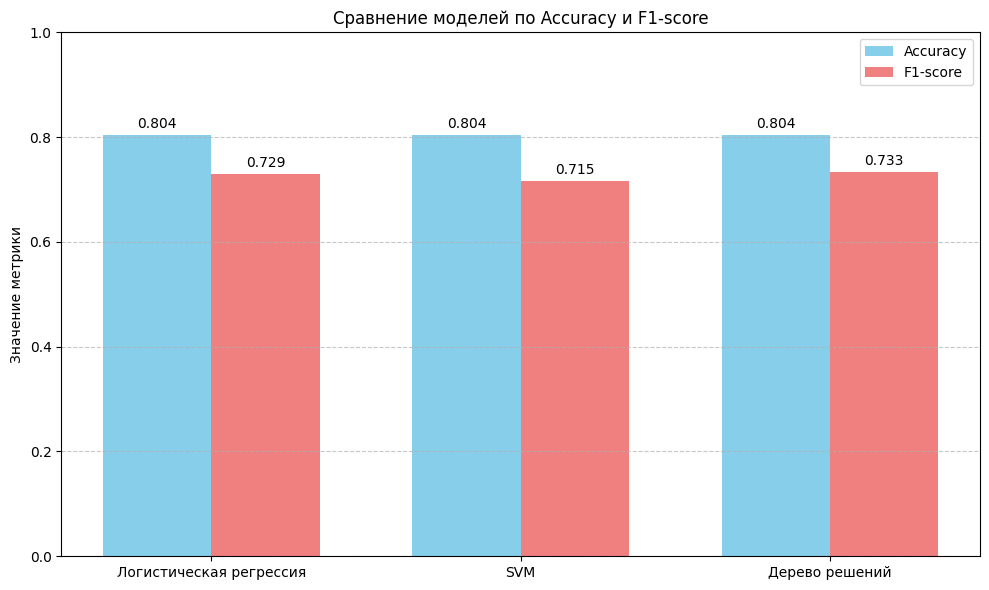

In [54]:
# --- Сравнение моделей по Accuracy и F1-score ---
models = ['Логистическая регрессия', 'SVM', 'Дерево решений']
accuracies = [accuracy_score(y_test, y_pred_lr), 
              accuracy_score(y_test, y_pred_svm), 
              accuracy_score(y_test, y_pred_dt)]
f1_scores = [f1_score(y_test, y_pred_lr), 
             f1_score(y_test, y_pred_svm), 
             f1_score(y_test, y_pred_dt)]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='skyblue')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-score', color='lightcoral')

ax.set_ylabel('Значение метрики')
ax.set_title('Сравнение моделей по Accuracy и F1-score')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim([0, 1])

# Подписи значений на столбцах
for rect in rects1:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

for rect in rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

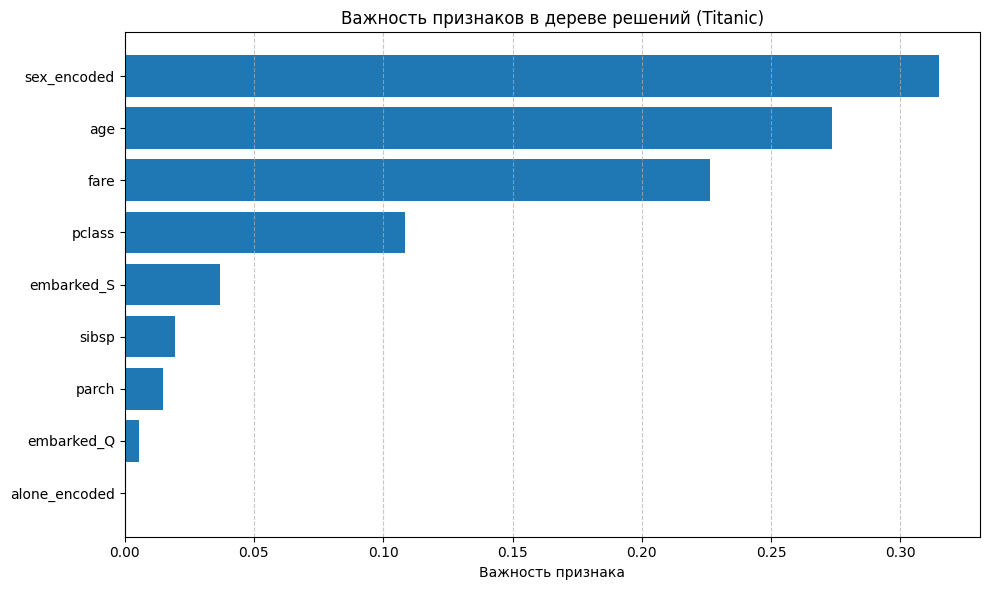

In [55]:
# --- График важности признаков ---
feature_importance = dt_model.feature_importances_
features = feature_columns  # у вас уже определен список

# Сортировка для красивого графика
sorted_idx = np.argsort(feature_importance)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(features)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(features)), np.array(features)[sorted_idx])
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений (Titanic)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

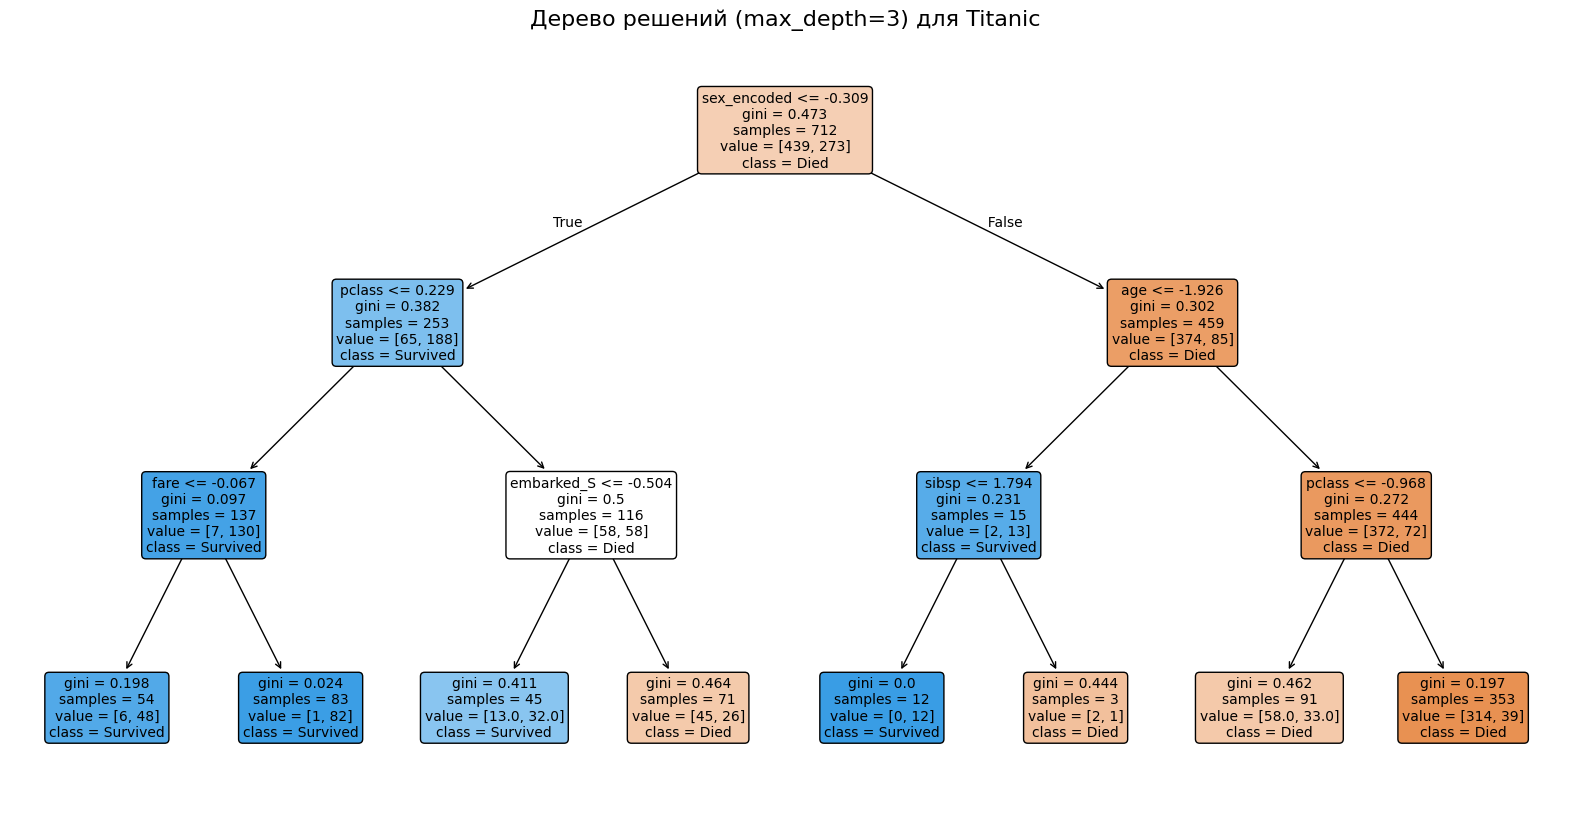


=== Правила дерева решений (текстовый вид) ===

|--- sex_encoded <= -0.31
|   |--- pclass <= 0.23
|   |   |--- fare <= -0.07
|   |   |   |--- class: 1
|   |   |--- fare >  -0.07
|   |   |   |--- class: 1
|   |--- pclass >  0.23
|   |   |--- embarked_S <= -0.50
|   |   |   |--- class: 1
|   |   |--- embarked_S >  -0.50
|   |   |   |--- class: 0
|--- sex_encoded >  -0.31
|   |--- age <= -1.93
|   |   |--- sibsp <= 1.79
|   |   |   |--- class: 1
|   |   |--- sibsp >  1.79
|   |   |   |--- class: 0
|   |--- age >  -1.93
|   |   |--- pclass <= -0.97
|   |   |   |--- class: 0
|   |   |--- pclass >  -0.97
|   |   |   |--- class: 0



In [59]:
dt_viz_model = DecisionTreeClassifier(random_state=42, max_depth=3)
dt_viz_model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(dt_viz_model, 
          feature_names=feature_columns,
          class_names=['Died', 'Survived'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title("Дерево решений (max_depth=3) для Titanic", fontsize=16)
plt.show()

tree_rules = export_text(dt_viz_model, feature_names=feature_columns)
print("\n=== Правила дерева решений (текстовый вид) ===\n")
print(tree_rules)